In [ ]:
#!pip install bpnet-lite

In [ ]:
!bpnet negatives -i "../../examples/ENCSR000AKO.bed" -f "/home/haotingc/scratch_mcieslik/Lyra_model/genome/hg38.fa" -o "../../examples/ENCSR000AKO_negatives.bed" -w 2114 -x 1000 -v

In [1]:
!bpnet fit -p bpnet_fit_example.json

/bin/bash: bpnet: command not found


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

log = pd.read_table("example.log")
log

,Epoch,Iteration,Training Time,Validation Time,Training MNLL,Training Count MSE,Validation MNLL,Validation Profile Pearson,Validation Count Pearson,Validation Count MSE,Saved?
0,0,0,1.986231,0.802908,438.631348,15.085032,622.128296,-0.002232,-0.128337,9.949596,True
1,0,100,2.977514,0.701998,417.762329,1.989936,301.404388,0.050543,-0.156944,0.745472,True
2,0,200,2.826118,0.682532,408.308868,1.947769,284.976105,0.126186,-0.154690,1.054107,True
3,0,300,2.800694,0.641403,443.822266,1.751623,268.378082,0.200072,-0.078602,0.634185,True
4,0,400,2.759051,0.627359,386.371094,1.486923,256.651642,0.235328,0.303504,0.590804,True
...,...,...,...,...,...,...,...,...,...,...,...
284,21,28400,2.930480,0.624710,385.932495,0.875822,243.376587,0.281667,0.614008,1.106864,False
285,21,28500,2.733739,0.634277,330.456390,0.665019,243.288391,0.281750,0.604651,1.126015,False
286,21,28600,2.823962,1.024334,326.229187,0.649065,243.735657,0.280986,0.615883,1.017027,False
287,21,28700,3.135293,0.637121,332.317383,0.606440,243.512573,0.281447,0.608227,0.853881,False


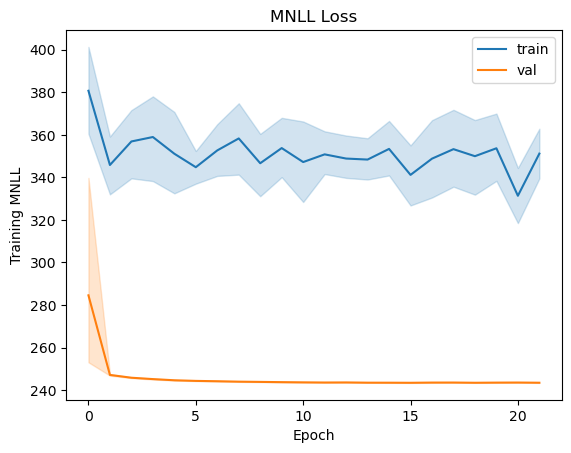

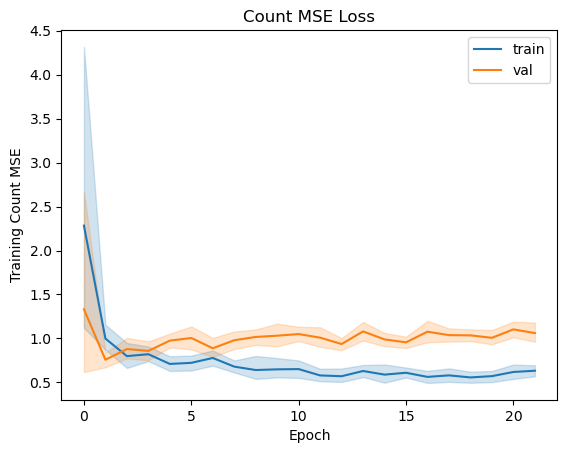

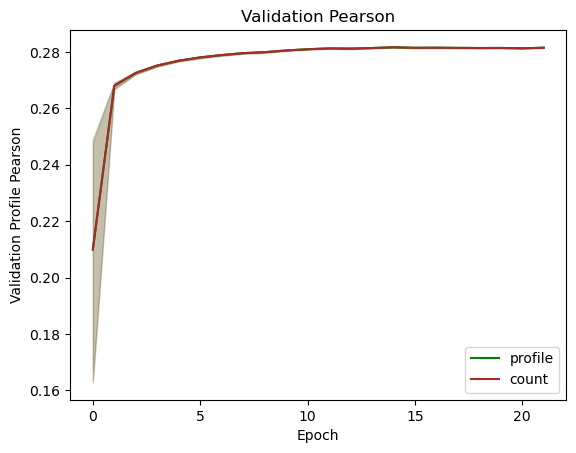

In [4]:
sns.lineplot(data=log, x="Epoch", y="Training MNLL", label="train")
sns.lineplot(data=log, x="Epoch", y="Validation MNLL", label="val")
plt.title("MNLL Loss")
plt.show()

sns.lineplot(data=log, x="Epoch", y="Training Count MSE", label="train")
sns.lineplot(data=log, x="Epoch", y="Validation Count MSE", label="val")
plt.title("Count MSE Loss")
plt.show()

sns.lineplot(data=log, x="Epoch", y="Validation Profile Pearson", color="green", label="profile")
sns.lineplot(data=log, x="Epoch", y="Validation Profile Pearson", color="brown", label="count")
plt.title("Validation Pearson")
plt.show()

In [ ]:
!bpnet predict -p bpnet_predict_example.json

In [1]:
import numpy as np
import torch

y_profile = np.load("y_profile.npz")
print(list(y_profile.keys()))
y_profile = y_profile["arr_0"]

y_counts = np.load("y_counts.npz")
print(list(y_counts.keys()))
y_counts = y_counts["arr_0"]

print(y_profile.shape, y_counts.shape) # batch, strands, seq_len

['arr_0']
['arr_0']
(4634, 2, 1000) (4634, 1)


In [2]:
# get ground truth
from tangermeme.io import extract_loci
import json

with open("bpnet_fit_example.json", "r") as f:
    parameters = json.load(f)

parameters['controls'] = None

valid_data = extract_loci(
    sequences=parameters['sequences'],
    signals=parameters['signals'],
    in_signals=parameters['controls'],
    loci=parameters['loci'],
    chroms=parameters['validation_chroms'],
    in_window=parameters['in_window'],
    out_window=parameters['out_window'],
    max_jitter=0,
    ignore=list('QWERYUIOPSDFHJKLZXVBNM'),
    verbose=parameters['verbose']
)
print(valid_data[0].shape, valid_data[1].shape) # sequences and signals

Loading Loci: 100%|██████████| 4634/4634 [00:10<00:00, 457.68it/s] 


torch.Size([4634, 4, 2114]) torch.Size([4634, 2, 1000])


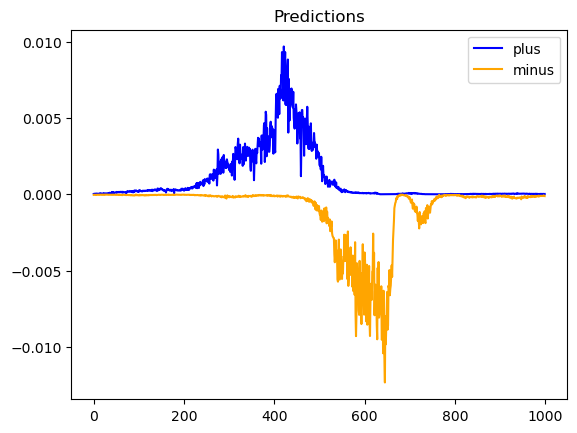

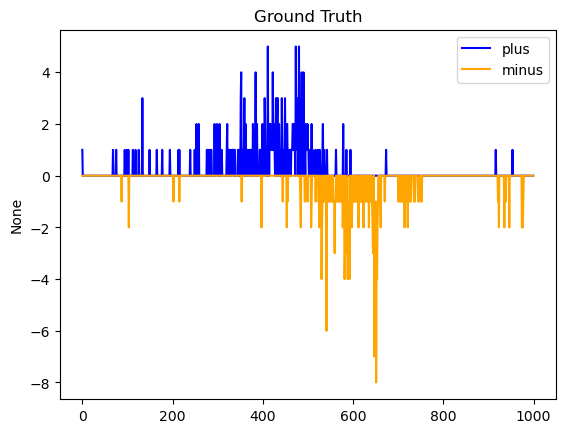

In [5]:
idx = 100

def softmax(x):
    """Compute softmax values for each sets of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

# predictions
y = y_profile[idx, 0, :]
y = softmax(y)
x = np.arange(len(y))
sns.lineplot(x=x, y=y, label="plus", color="blue")

y = y_profile[idx, 1, :]
y = softmax(y)
x = np.arange(len(y))
sns.lineplot(x=x, y=-y, label="minus", color="orange")
plt.title("Predictions")
plt.show()

# ground truth
y = valid_data[1][idx, 0, :]
x = np.arange(len(y))
sns.lineplot(x=x, y=y, label="plus", color="blue")

y = valid_data[1][idx, 1, :]
x = np.arange(len(y))
sns.lineplot(x=x, y=-y, label="minus", color="orange")
plt.title("Ground Truth")
plt.show()